In [ ]:
# fitting
!git clone https://github.com/kaifengZheng/Zanes.git

# dataprocessing

In [13]:
import numpy as np
import pandas as pd
from zanes.data_analysis import data_processing as dp
from zanes.data_analysis import zanes_data_analysis as zda
from zanes.data_analysis import wavelet_transform as wt
from glob import glob
import toml
import matplotlib.pyplot as plt
from os.path import join,exists,basename,exists
from os import makedirs


filename='test_data/pd.prj'
exp_data=zda(filename,datatype='Athena',batch_size=None,read_range=None)

In [14]:
exp_data.data

[<Group 0x7f0f05d987d0>, <Group 0x7f0f05f40e50>, <Group 0x7f0f05d98910>]

In [15]:
data_param={'pre_start':-200,
               'pre_end':-70,
               'post_start':71,
               'post_end':800,
               'kweight':2,'rbkg':1.5,
               'E0':23457,
               'krange':[2,15]}

fit_range_param={'kmin':2,
                 'kmax':15,
                 'kw':2,
                 'dk':2,
                 'window':'hanning',
                 'rmin':1.646,
                 'rmax':3.292}

In [16]:
exp_data.process_data(data_param)

E0=24356.6


24356.6

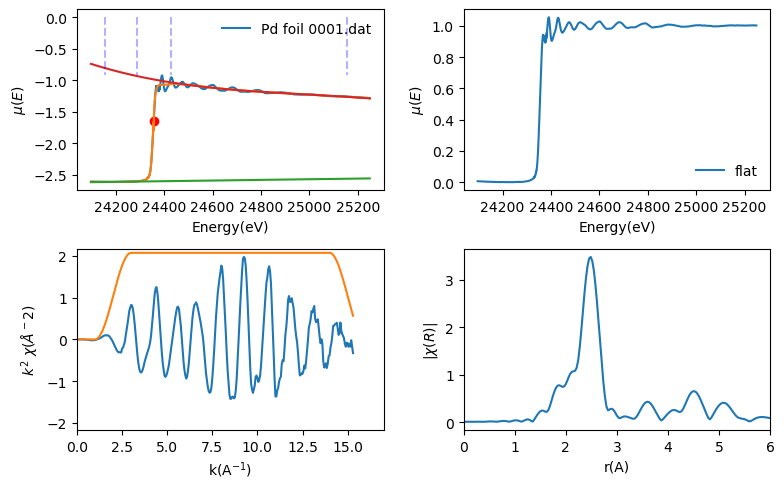

In [17]:
exp_data=zda(filename,datatype='Athena',batch_size=None,read_range=None)

aa=dp(exp_data.data[1],pre_start=data_param['pre_start'],
                      pre_end=data_param['pre_end'],
               post_start=data_param['post_start'],
               post_end=data_param['post_end'],
               kweight=data_param['kweight'],rbkg=data_param['rbkg'],
               krange=data_param['krange'],plot=True)
exp_data.data[1].e0

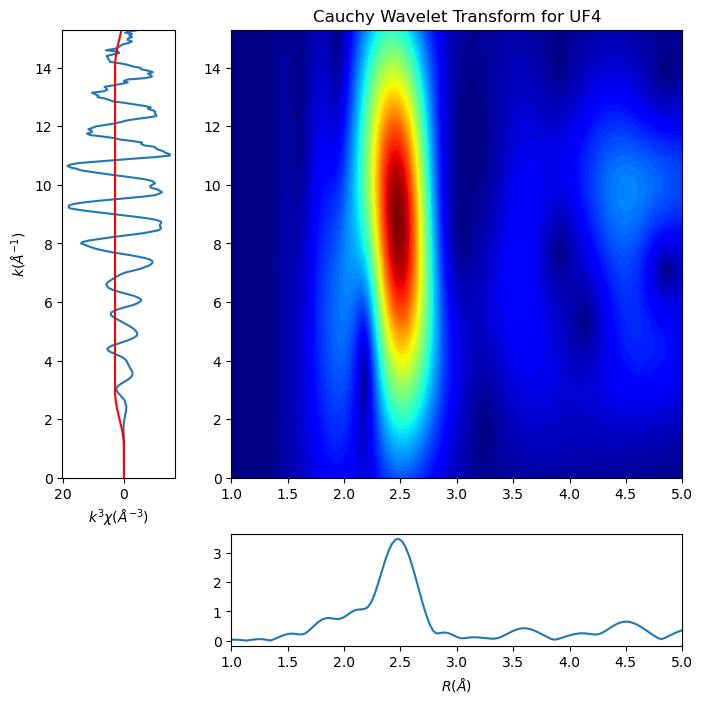

In [18]:
wt(group=exp_data.data[1],kweight=2,plot=True)

In [6]:

filenames=glob('test_data/*.prj')
# basename(filenames[0])
filenames[0][:-4]

'test_data/pd'

In [7]:
data_param={'pre_start':-200,
               'pre_end':-70,
               'post_start':71,
               'post_end':800,
               'kweight':2,'rbkg':1,
               'E0':23457,
               'krange':[2,15]}

fit_range_param={'kmin':2,
                 'kmax':15,
                 'kw':2,
                 'dk':2,
                 'window':'hanning',
                 'rmin':1.646,
                 'rmax':3}
param_dict={
    'SO2':{"SO2":{'initial':0.78,'vary':False,'global':False}},
    'dele':{'dele_Pt':{'initial':0.0,'vary':True,'global':False}},
    'ss2':{'ss2_Pt':{'initial':0.003,'vary':True,'global':False,
                    'thermal':{'type':False,
                     'theta':{'initial':400,'vary':True,'global':True}}}},
    'N':{'N_Pt':{'initial':12.0,'vary':True,'global':False}},
    'delr':{'delr_Pt':{'initial':0.0,'vary':True,'global':False}},
}

# for file in filenames:
file_name=basename(filenames[0])
foldername=join('test_data/results',file_name[:-4]+'rbkg1')
if not exists(foldername):
    makedirs(foldername)
exp_data=zda(filenames[0],datatype='Athena',batch_size=1)
exp_data.process_data(data_param)
save_path=join(foldername,file_name[:-4]+'_rbkg1.txt')
dset,out,report,path=exp_data.run_fit_batch(param_dict=param_dict,fit_range_param=fit_range_param,fitpath_num=[0],feff_folder='test_data/feff',save_name=save_path,mpi=False,core=10,write=True)
report_sort=exp_data.write_sorted_report(out,report,param_dict,path[0])
exp_data.write_fitted_data(dset,filenames[0],foldername,suffix='_rbkg1')

output_fit = join(foldername,file_name[:-4]+'_rbkg1.toml')
with open(output_fit, "w") as f:
    toml.dump(report_sort,f)
    

100%|██████████| 3/3 [00:00<00:00, 37.07it/s]

pd.prj


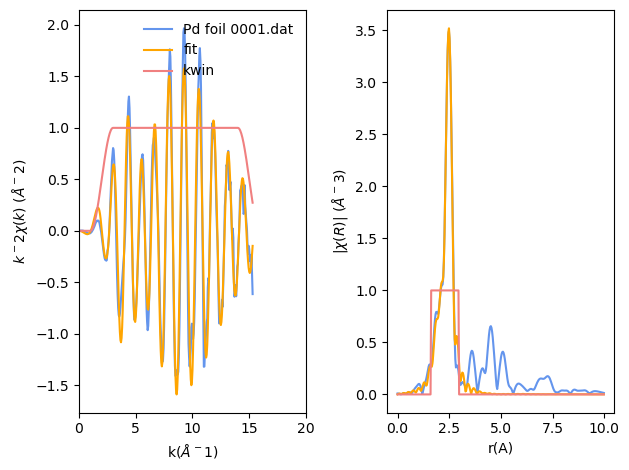

In [12]:
exp_data.plot_fitting_batch_results(1,dset,d_range=[0,1])